In [1]:
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, roc_auc_score
from torch import nn
import openml
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tfmplayground.callbacks import ConsoleLoggerCallback, WandbLoggerCallback
from tfmplayground.evaluation import get_openml_predictions, TOY_TASKS_CLASSIFICATION, TABARENA_TASKS
from tfmplayground.interface import NanoTabPFNClassifier
from tfmplayground.model import NanoTabPFNModel
from tfmplayground.priors import PriorDumpDataLoader
from tfmplayground.train import train
from tfmplayground.utils import get_default_device, set_randomness_seed

In [8]:
task_ids = TABARENA_TASKS

dataaset_infos = {}
for task_id in tqdm(task_ids):
    task = openml.tasks.get_task(task_id, download_splits=False)
    dataset = task.get_dataset(download_data=False)
    dataset_info = {
        'task_id' : task.task_id,
        'dataset_id' : task.dataset_id,
        'task_type_id' : task.task_type_id,
    }
    dataset_info.update(dataset.qualities)
    dataaset_infos[dataset.name] = dataset_info
df = pd.DataFrame.from_dict(dataaset_infos, orient='index').rename_axis('dataset_name')

100%|██████████| 51/51 [00:00<00:00, 591.82it/s]


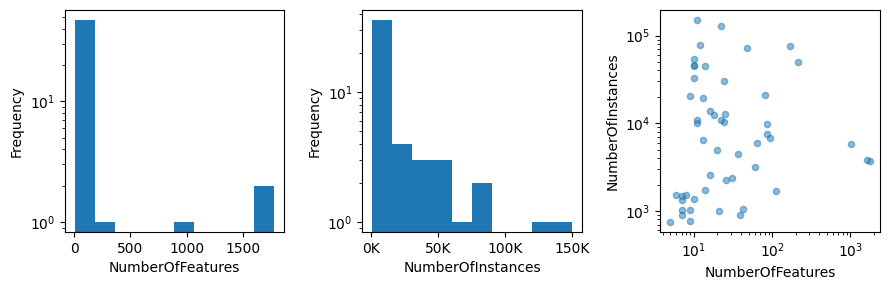

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3), tight_layout=True)

df.plot(kind='hist', y='NumberOfFeatures', bins=10, ax=axs[0], logy=True, legend=False, xlabel='NumberOfFeatures')
df.plot(kind='hist', y='NumberOfInstances', bins=10, ax=axs[1], logy=True, legend=False, xlabel='NumberOfInstances')
axs[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}K'))
df.plot(kind='scatter', x='NumberOfFeatures', y='NumberOfInstances', ax=axs[2], logx=True, logy=True, alpha=0.5)
plt.show()

In [11]:
df.to_csv('../../gtfm/logs/store/tabarena_dataset_infos.csv')